<a href="https://colab.research.google.com/github/Garemilla-Sandilya/2023Fall-BIOC-6223/blob/main/Human_Ewing_sarcoma_cell_line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scanpy anndata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.9 MB/s eta 0:00:00


In [ ]:
pip install scanpy anndata pandas numpy


In [ ]:
!tar -xvf GSE171205_RAW.tar
!gunzip *.gz

GSM5220743_CellList_EWS_SC.txt.gz
GSM5220743_allSamples_Genes_featureCount.txt.gz


In [ ]:
import pandas as pd
import scanpy as sc
import anndata

# Load count matrix
df = pd.read_csv('GSM5220743_allSamples_Genes_featureCount.txt', sep='\t', index_col=0).T

# Load cell annotations
df_anno = pd.read_csv('GSM5220743_CellList_EWS_SC.txt', sep='\t', index_col=0)

# Create AnnData
adata = anndata.AnnData(df)

# Add annotations
for col in df_anno.columns:
    adata.obs[col] = df_anno[col]

adata

AnnData object with n_obs × n_vars = 839 × 23228
    obs: 'SequencingBatch', 'Treatment', 'Clusters'

In [ ]:
adata.write_h5ad('EW8_adata.h5ad', compression='gzip')
print("Saved! Shape:", adata.shape)

Saved! Shape: (839, 23228)


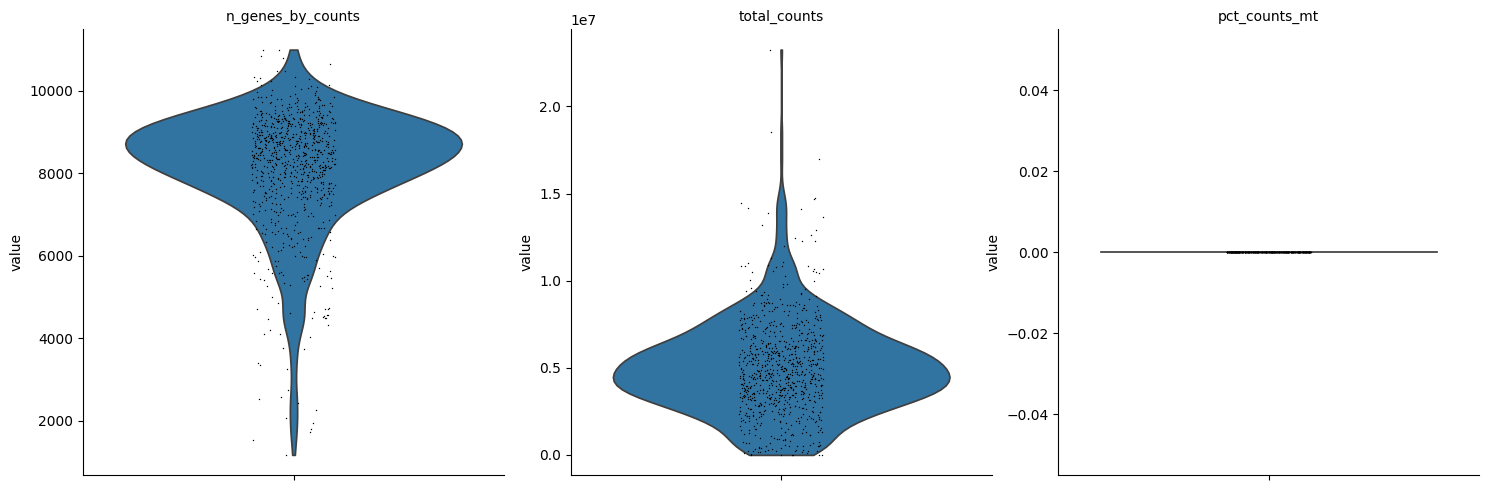

In [ ]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Plot QC
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], multi_panel=True)

In [ ]:
adata = adata[adata.obs.pct_counts_mt < 20, :].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)

(839, 17823)


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [ ]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/tmp/ipykernel_369/641390817.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


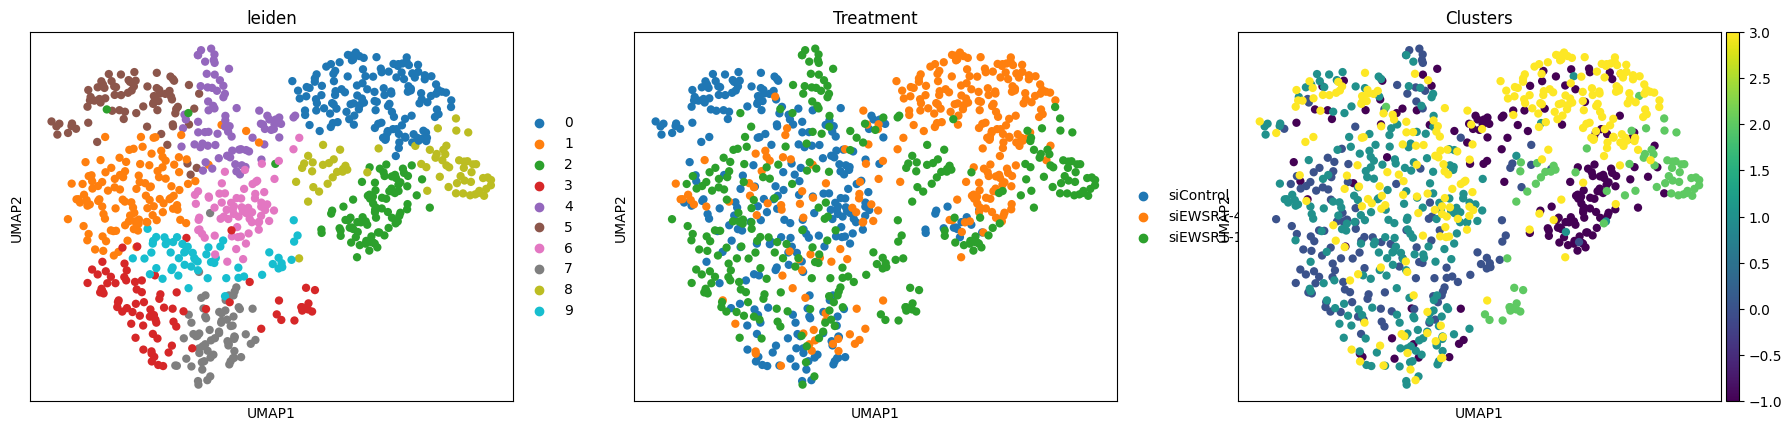

In [ ]:
sc.pl.umap(adata, color=['leiden', 'Treatment', 'Clusters'])

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: 

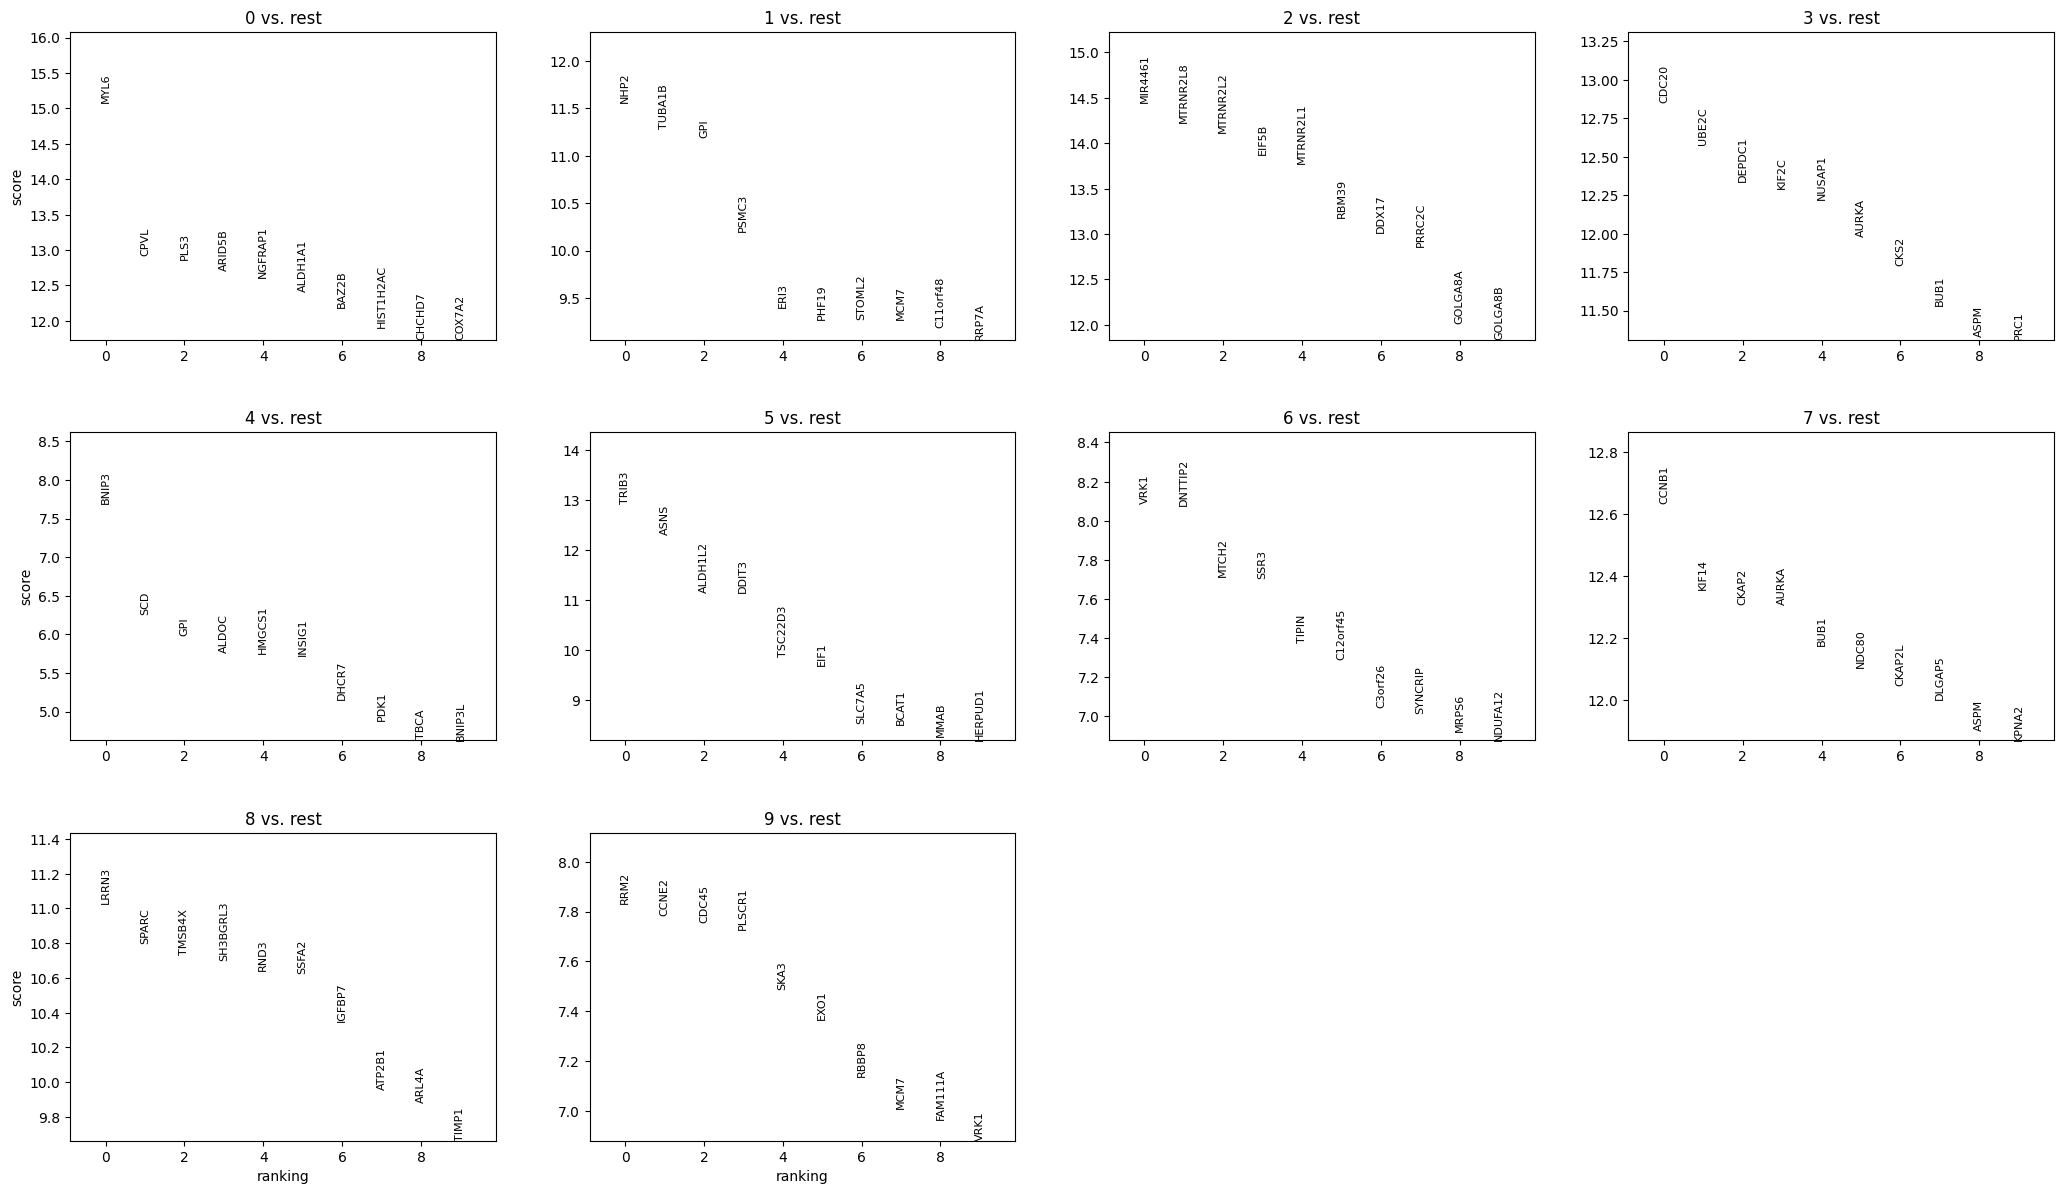

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [ ]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7,8,9
0,MYL6,NHP2,MIR4461,CDC20,BNIP3,TRIB3,VRK1,CCNB1,LRRN3,RRM2
1,CPVL,TUBA1B,MTRNR2L8,UBE2C,SCD,ASNS,DNTTIP2,KIF14,SPARC,CCNE2
2,PLS3,GPI,MTRNR2L2,DEPDC1,GPI,ALDH1L2,MTCH2,CKAP2,TMSB4X,CDC45
3,ARID5B,PSMC3,EIF5B,KIF2C,ALDOC,DDIT3,SSR3,AURKA,SH3BGRL3,PLSCR1
4,NGFRAP1,ERI3,MTRNR2L1,NUSAP1,HMGCS1,TSC22D3,TIPIN,BUB1,RND3,SKA3
5,ALDH1A1,PHF19,RBM39,AURKA,INSIG1,EIF1,C12orf45,NDC80,SSFA2,EXO1
6,BAZ2B,STOML2,DDX17,CKS2,DHCR7,SLC7A5,C3orf26,CKAP2L,IGFBP7,RBBP8
7,HIST1H2AC,MCM7,PRRC2C,BUB1,PDK1,BCAT1,SYNCRIP,DLGAP5,ATP2B1,MCM7
8,CHCHD7,C11orf48,GOLGA8A,ASPM,TBCA,MMAB,MRPS6,ASPM,ARL4A,FAM111A
9,COX7A2,RRP7A,GOLGA8B,PRC1,BNIP3L,HERPUD1,NDUFA12,KPNA2,TIMP1,VRK1


       'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP', 'HELLS', 'RFC2',
       'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'UBR7', 'POLD3',
       'MSH2', 'ATAD2', 'RAD51', 'CDC6', 'DSCC1', 'BLM', 'CASP8AP2', 'USP1',
       'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8'],
      dtype='object')
       'FAM64A', 'SMC4', 'CCNB2', 'AURKB', 'ANP32E', 'TUBB4B', 'GTSE1',
       'HJURP', 'CDCA3', 'HN1', 'TTK', 'CDC25C', 'RANGAP1', 'NCAPD2', 'CDCA2',
       'CDCA8', 'ECT2', 'KIF23', 'HMMR', 'PSRC1', 'ANLN', 'LBR', 'CKAP5',
       'CTCF', 'NEK2', 'G2E3', 'GAS2L3', 'CBX5', 'CENPA'],
      dtype='object')


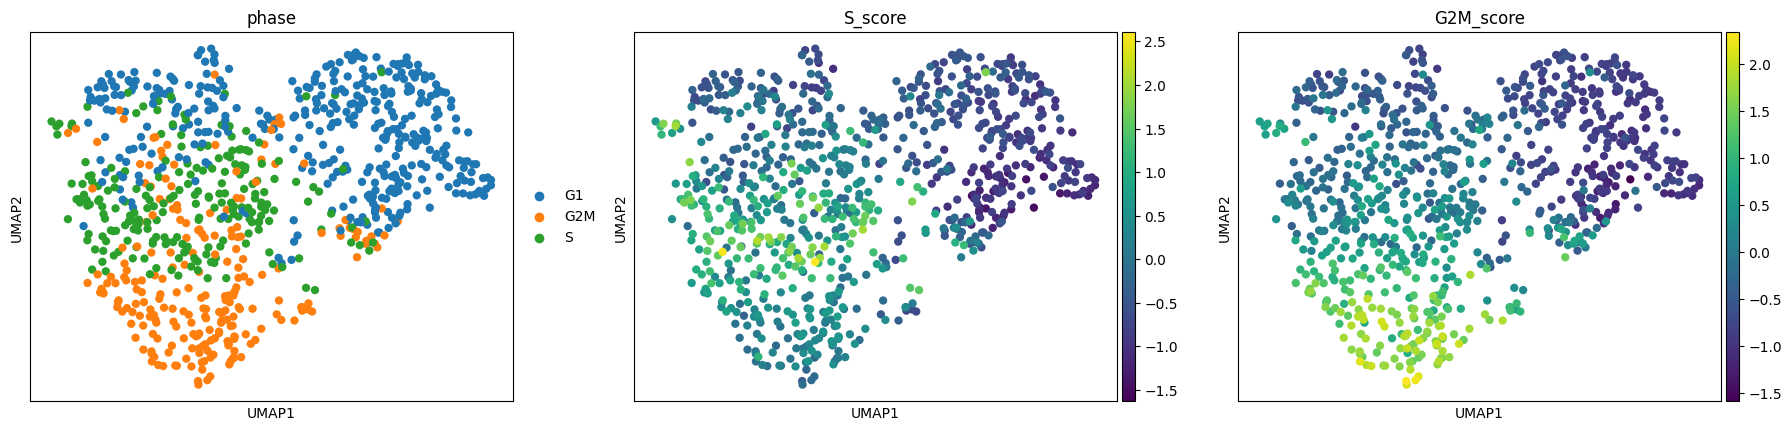

In [ ]:
s_genes = ['MCM5','PCNA','TYMS','FEN1','MCM2','MCM4','RRM1','UNG','GINS2','MCM6','CDCA7','DTL','PRIM1','UHRF1','MLF1IP','HELLS','RFC2','RPA2','NASP','RAD51AP1','GMNN','WDR76','SLBP','CCNE2','UBR7','POLD3','MSH2','ATAD2','RAD51','RRM2','CDC45','CDC6','EXO1','TIPIN','DSCC1','BLM','CASP8AP2','USP1','CLSPN','POLA1','CHAF1B','BRIP1','E2F8']
g2m_genes = ['HMGB2','CDK1','NUSAP1','UBE2C','BIRC5','TPX2','TOP2A','NDC80','CKS2','NUF2','CKS1B','MKI67','TMPO','CENPF','TACC3','FAM64A','SMC4','CCNB2','CKAP2L','CKAP2','AURKB','BUB1','KIF11','ANP32E','TUBB4B','GTSE1','KIF20B','HJURP','CDCA3','HN1','CDC20','TTK','CDC25C','KIF2C','RANGAP1','NCAPD2','DLGAP5','CDCA2','CDCA8','ECT2','KIF23','HMMR','AURKA','PSRC1','ANLN','LBR','CKAP5','CENPE','CTCF','NEK2','G2E3','GAS2L3','CBX5','CENPA']

sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pl.umap(adata, color=['phase', 'S_score', 'G2M_score'])

       'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP', 'HELLS', 'RFC2',
       'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'UBR7', 'POLD3',
       'MSH2', 'ATAD2', 'RAD51', 'CDC6', 'DSCC1', 'BLM', 'CASP8AP2', 'USP1',
       'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8'],
      dtype='object')
       'FAM64A', 'SMC4', 'CCNB2', 'AURKB', 'ANP32E', 'TUBB4B', 'GTSE1',
       'HJURP', 'CDCA3', 'HN1', 'TTK', 'CDC25C', 'RANGAP1', 'NCAPD2', 'CDCA2',
       'CDCA8', 'ECT2', 'KIF23', 'HMMR', 'PSRC1', 'ANLN', 'LBR', 'CKAP5',
       'CTCF', 'NEK2', 'G2E3', 'GAS2L3', 'CBX5', 'CENPA'],
      dtype='object')


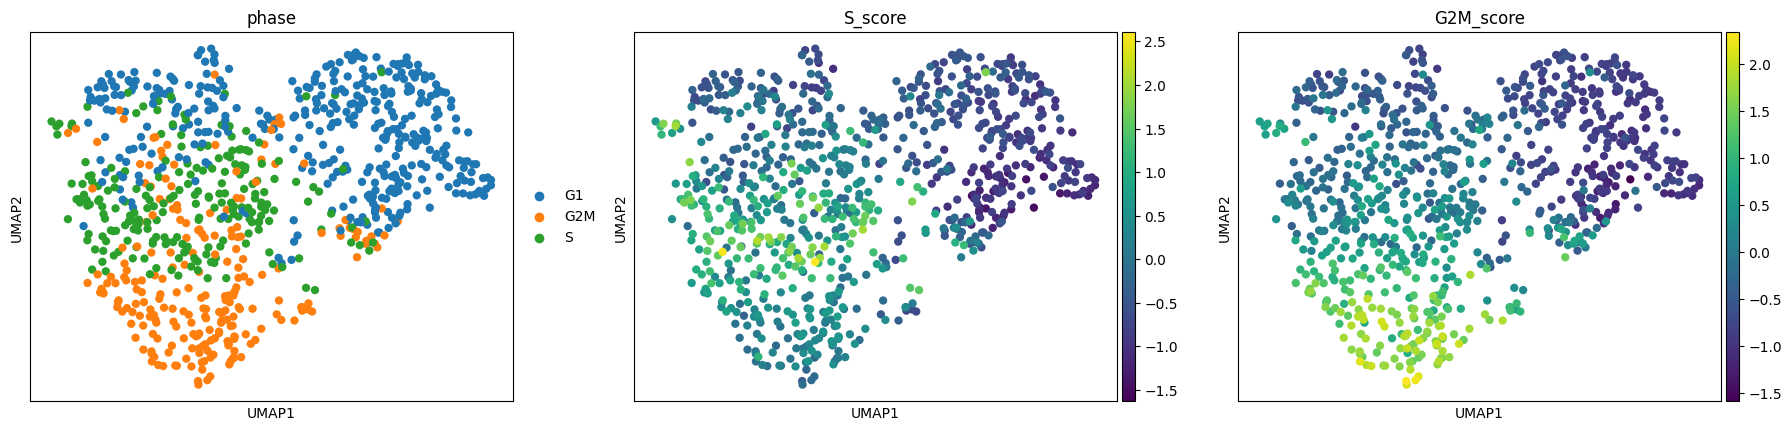

In [ ]:
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes, use_raw=True)
sc.pl.umap(adata, color=['phase', 'S_score', 'G2M_score'])

In [ ]:
# Check what's actually in the data
print([g for g in adata.raw.var_names if 'MCM' in g.upper()])
print([g for g in adata.raw.var_names if 'MKI' in g.upper()])
print([g for g in adata.raw.var_names if 'TOP2' in g.upper()])

['MCM7']
[]
['TOP2A']


In [ ]:
all_genes = set(adata.raw.var_names)

s_found = [g for g in s_genes if g in all_genes]
g2m_found = [g for g in g2m_genes if g in all_genes]

print(f"S genes found: {len(s_found)}/43 → {s_found}")
print(f"G2M genes found: {len(g2m_found)}/54 → {g2m_found}")

S genes found: 5/43 → ['CCNE2', 'RRM2', 'CDC45', 'EXO1', 'TIPIN']
G2M genes found: 17/54 → ['CDK1', 'NUSAP1', 'UBE2C', 'TOP2A', 'NDC80', 'CKS2', 'CENPF', 'CKAP2L', 'CKAP2', 'BUB1', 'KIF11', 'KIF20B', 'CDC20', 'KIF2C', 'DLGAP5', 'AURKA', 'CENPE']


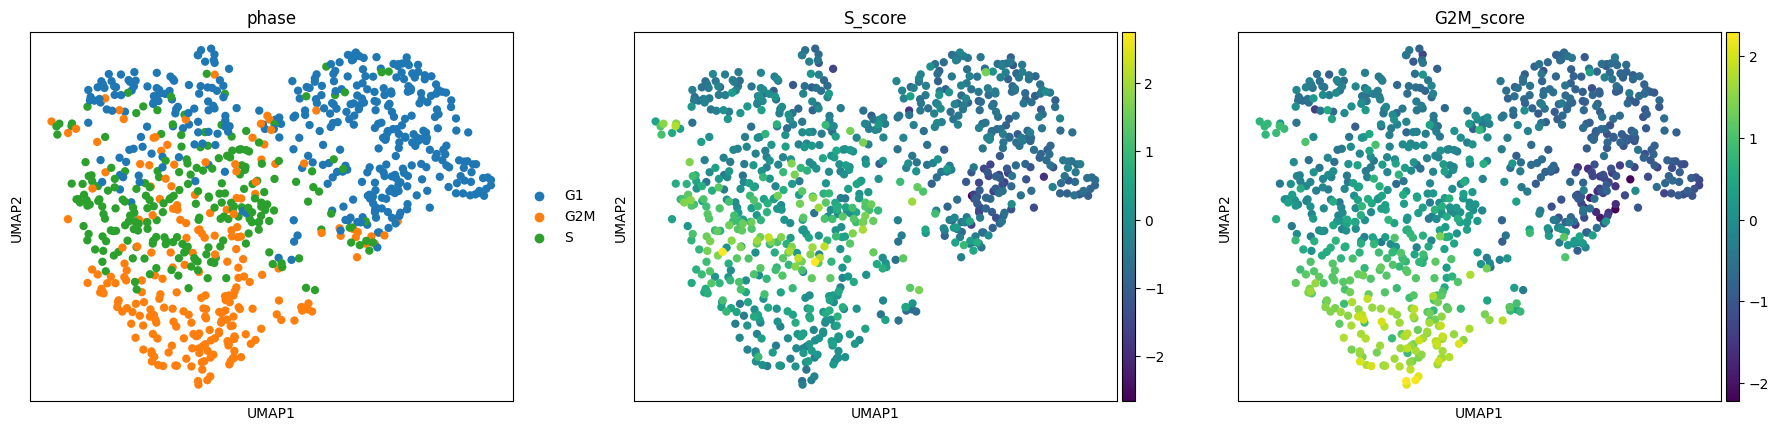

In [ ]:
s_found = ['CCNE2', 'RRM2', 'CDC45', 'EXO1', 'TIPIN']
g2m_found = ['CDK1', 'NUSAP1', 'UBE2C', 'TOP2A', 'NDC80', 'CKS2', 'CENPF', 'CKAP2L', 'CKAP2', 'BUB1', 'KIF11', 'KIF20B', 'CDC20', 'KIF2C', 'DLGAP5', 'AURKA', 'CENPE']

sc.tl.score_genes_cell_cycle(adata, s_genes=s_found, g2m_genes=g2m_found, use_raw=True)
sc.pl.umap(adata, color=['phase', 'S_score', 'G2M_score'])

In [ ]:
adata.write_h5ad('EW8_final.h5ad', compression='gzip')
print("Done!", adata.shape)

Done! (839, 2000)


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


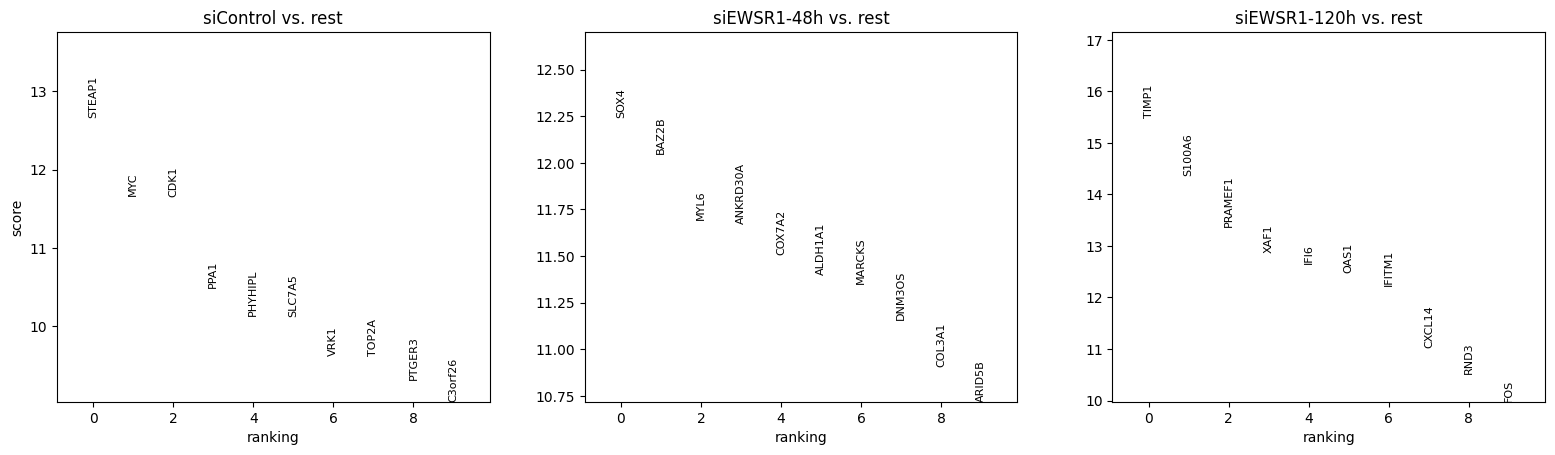

In [ ]:
sc.tl.rank_genes_groups(adata, 'Treatment', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [ ]:
marker_genes = ['MKI67','TOP2A','CDC20','CCNB1','AURKA','TRIB3','ASNS','DDIT3','SPARC','LMNA','ALDOC','NRP2','PLS3']
found = [g for g in marker_genes if g in adata.raw.var_names]
missing = [g for g in marker_genes if g not in adata.raw.var_names]
print(f"Found: {found}")
print(f"Missing: {missing}")

Found: ['TOP2A', 'CDC20', 'CCNB1', 'AURKA', 'TRIB3', 'ASNS', 'DDIT3', 'SPARC', 'ALDOC', 'PLS3']
Missing: ['MKI67', 'LMNA', 'NRP2']


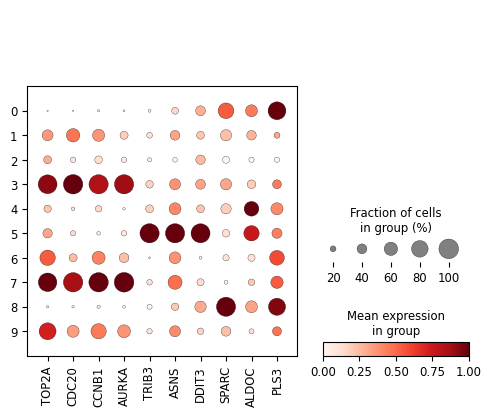

In [ ]:
found = ['TOP2A', 'CDC20', 'CCNB1', 'AURKA', 'TRIB3', 'ASNS', 'DDIT3', 'SPARC', 'ALDOC', 'PLS3']
sc.pl.dotplot(adata, found, groupby='leiden', standard_scale='var', use_raw=True)

categories: 0, 1, 2, etc.
var_group_labels: siControl, siEWSR1-48h, siEWSR1-120h


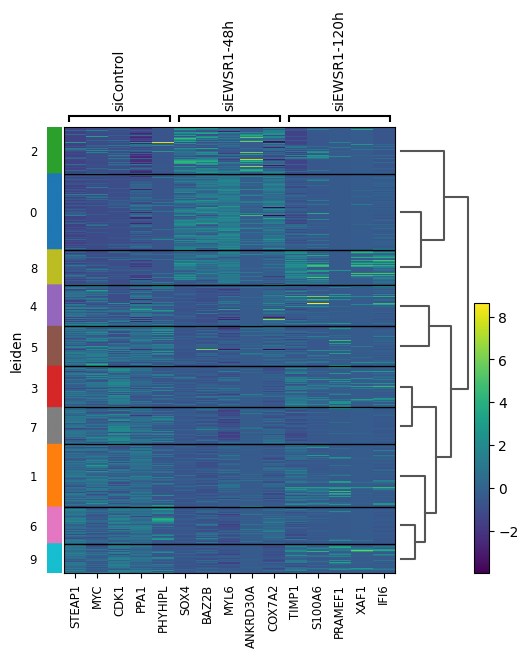

In [ ]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby='leiden', show_gene_labels=True)

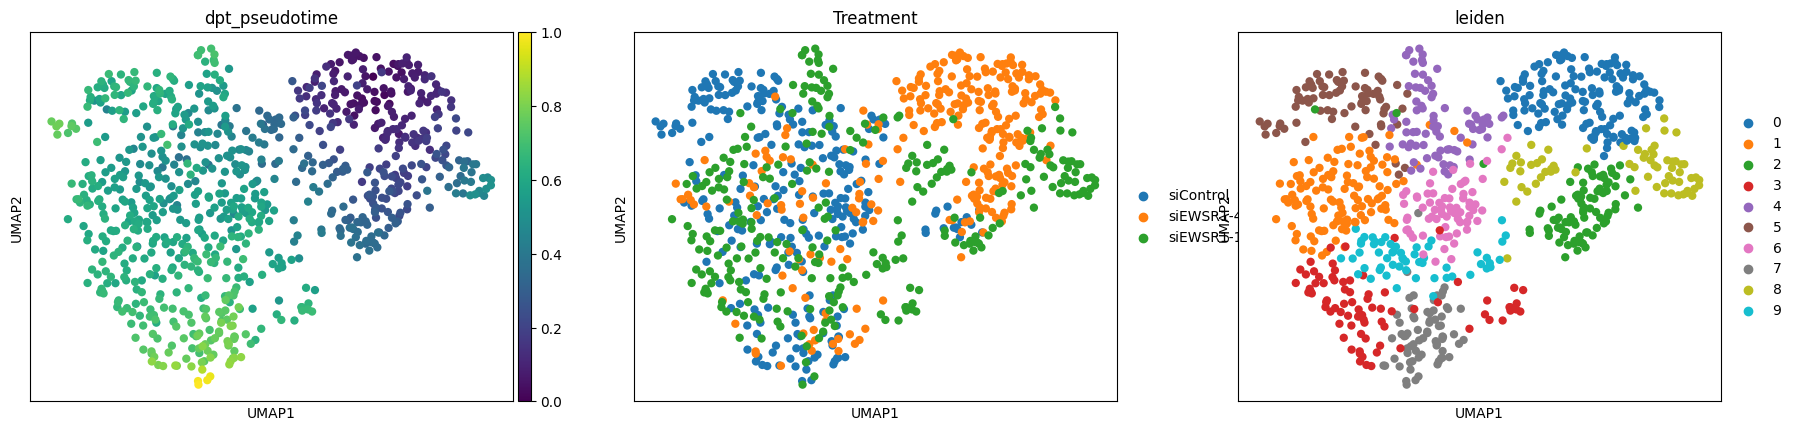

In [ ]:
sc.tl.diffmap(adata)

# Set root cell (pick a cell from the largest/main cluster)
adata.uns['iroot'] = int(np.where(adata.obs['leiden'] == '0')[0][0])

sc.tl.dpt(adata, n_dcs=10)
sc.pl.umap(adata, color=['dpt_pseudotime', 'Treatment', 'leiden'])

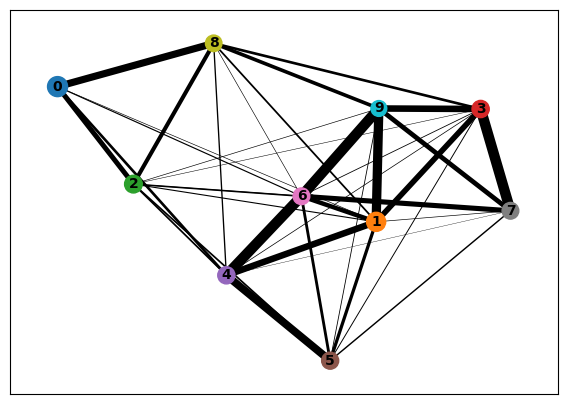

In [ ]:
sc.tl.paga(adata, groups='leiden')
sc.pl.paga(adata, threshold=0.03)

In [ ]:
adata.write_h5ad('EW8_complete.h5ad', compression='gzip')
print("All done!", adata)

All done! AnnData object with n_obs × n_vars = 839 × 2000
    obs: 'SequencingBatch', 'Treatment', 'Clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'S_score', 'G2M_score', 'phase', 'dpt_pseudotime'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Treatment_colors', 'rank_genes_groups', 'phase_colors', 'dendrogram_leiden', 'diffmap_evals', 'iroot', 'paga', 'leiden_sizes'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [ ]:
!pip install leidenalg igraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 106.8 MB/s eta 0:00:00
